In [286]:
#source('/research_jude/rgs01_jude/groups/jxugrp/home/common/Lab_Members/WenhuoHu/script/utils.r')
base_dir = '/scratch/mjehangir/manuscript_figures/figures'
setwd(base_dir)

In [287]:
# Load required libraries
library(tidyverse)
library(corrplot)
library(ggpubr)
#library(ggpubr)
library(tidyverse)
library(readxl)
#library(DESeq2)
library(dplyr)
library(ggplot2)
library(gridExtra)
library(ggrepel)
library(ComplexHeatmap)
library(tidyr)
library(dplyr)
#library(GGally)
library(data.table)  # For fread()

In [414]:
final_df = read.csv(file = "final_merged_for_correlation_analysis_v3.tsv", header = TRUE, sep = "\t")

In [415]:
head(final_df, n=2)

,SampleID,assigned_arm,chr,Length,total_length_neutral,total_length_gain,total_length_loss,proportion_neutral,proportion_gain,proportion_loss,final_average_TL_p75,chr_order,arm,arm_call,arm_num_seg,arm_cr_wmean,type,n_SV,total_size,SVs_density
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<int>,<int>,<dbl>,<chr>,<int>,<dbl>,<dbl>
1,2436A,chr10q,chr10,94108943,26230785,0,18621836,0.2787279,0,0.1978753,2732.75,10,q,0,5,0.9870386,DEL,469,159358,0.7941742795
2,2436A,chr10q,chr10,94108943,26230785,0,18621836,0.2787279,0,0.1978753,2732.75,10,q,0,5,0.9870386,DUP,1,23673,0.0002515489


In [396]:
head(final_df, n=10)


,SampleID,chr,arm,SV_density,proportion_gain,proportion_loss,final_average_TL_p75,arm_call,arm_num_seg,arm_cr_wmean,INS_density,DEL_density,DUP_density,INV_density,BND_density
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,3988,chr10,p,0.16738511,0.7930745,0.00000000,3769.75,1,4,1.2123989,0.08329465,0.08355992,0.0000000000,0.0005305392,0
2,6266D,chr10,p,0.05396772,0.8374078,0.00000000,5948.00,1,8,1.3019724,0.00000000,0.05396772,0.0000000000,0.0000000000,0
3,6269C,chr10,p,0.06616382,0.0689630,0.00000000,3778.50,0,3,1.0198296,0.00000000,0.05954744,0.0007939659,0.0058224163,0
4,6285B,chr10,p,0.06000000,0.0000000,0.00000000,4350.00,0,5,1.0197489,0.00000000,0.06000000,0.0000000000,0.0000000000,0
5,6298B,chr10,p,0.06462407,0.0000000,0.00000000,4781.50,0,3,0.9777848,0.00000000,0.06441493,0.0000000000,0.0002091394,0
6,6314E,chr10,p,0.02172778,0.0000000,0.00000000,9573.00,0,NA,NA,0.00000000,0.02162332,0.0000000000,0.0001044605,0
7,6423A,chr10,p,0.07130215,0.2512223,0.00000000,3955.00,0,NA,NA,0.00000000,0.07130215,0.0000000000,0.0000000000,0
8,6436B,chr10,p,0.03774047,0.4088520,0.00000000,8161.00,NA,8,1.5448393,0.00000000,0.03627006,0.0001225340,0.0013478740,0
9,6478A,chr10,p,0.09325459,0.5122965,0.01477778,3217.00,NA,5,1.7241142,0.00000000,0.08952440,0.0003108486,0.0034193348,0


In [397]:
library(dplyr)

#final_df_transformed <- final_df %>%
 # mutate(Group = if_else(is.na(arm_cr_wmean), "Non_ploidy", "ploidy")) %>%
  #select(Group, DEL_density, INV_density, INV_density, DUP_density, BND_density, SampleID, chr, arm, arm_call, arm_cr_wmean, proportion_gain, proportion_loss)

 #View the first 2 rows of the transformed data
#head(final_df_transformed, n = 20)


In [398]:
#final_df_transformed <- final_df %>%
 # mutate(Group = if_else(is.na(arm_call) | arm_call == 0, "Non_ploidy", "ploidy")) %>%
  #select(Group, DEL_density, INV_density, DUP_density, BND_density, INS_density, SampleID, chr, arm, arm_call, arm_cr_wmean)
# View the first 50 rows of the transformed data
#head(final_df_transformed, n = 50)

In [399]:
final_df_transformed <- final_df %>%
 filter(!is.na(arm_call)) %>%  # Remove NA values
  mutate(Group = case_when(
    arm_call %in% c(1, -1) ~ "ploidy",
    arm_call == 0 ~ "Non_ploidy",
   TRUE ~ NA_character_  # Ensure other values are not included
 )) %>%
  filter(!is.na(Group)) %>%  # Remove rows where Group is NA
 select(Group, SV_density, DEL_density, INV_density, DUP_density, BND_density, SampleID, chr, arm, arm_call, arm_cr_wmean, proportion_gain, proportion_loss)

# View the first 20 rows of the transformed data
#head(final_df_transformed, n = 2)


In [412]:
head(final_df_transformed)

,Group,SV_density,DEL_density,INV_density,DUP_density,BND_density,SampleID,chr,arm,arm_call,arm_cr_wmean,proportion_gain,proportion_loss
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,ploidy,0.16738511,0.08355992,0.0005305392,0.0000000000,0,3988,chr10,p,1,1.2123989,0.7930745,0
2,ploidy,0.05396772,0.05396772,0.0000000000,0.0000000000,0,6266D,chr10,p,1,1.3019724,0.8374078,0
3,Non_ploidy,0.06616382,0.05954744,0.0058224163,0.0007939659,0,6269C,chr10,p,0,1.0198296,0.0689630,0
4,Non_ploidy,0.06000000,0.06000000,0.0000000000,0.0000000000,0,6285B,chr10,p,0,1.0197489,0.0000000,0
5,Non_ploidy,0.06462407,0.06441493,0.0002091394,0.0000000000,0,6298B,chr10,p,0,0.9777848,0.0000000,0
6,Non_ploidy,0.02172778,0.02162332,0.0001044605,0.0000000000,0,6314E,chr10,p,0,NA,0.0000000,0


In [400]:
nrow(final_df_transformed)

[1] 426

In [413]:
final_df_transformed_p_arm =final_df_transformed %>% filter(arm == "p")
final_df_transformed_q_arm =final_df_transformed %>% filter(arm == "q")


In [402]:
#final_df_transformed %>% filter(proportion_gain < 0.1) %>% head()

In [403]:
#final_df_transformed_p_arm = final_df_transformed_p_arm %>% filter(DEL_density > 0 & DUP_density > 0)

In [404]:
#head(final_df_transformed_p_arm, n=20)
#final_df_transformed_p_arm %>% filter(if_any(everything(), is.na))

In [405]:
merged_p_q = final_df_transformed

In [406]:
merged_p_q = merged_p_q %>% filter(DEL_density > 0 & DUP_density > 0)

In [407]:
final_df_transformed_p_arm = final_df_transformed_p_arm %>% filter(DEL_density > 0 & DUP_density > 0)

Warning message in stat_compare_means(method = "t.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "t.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”


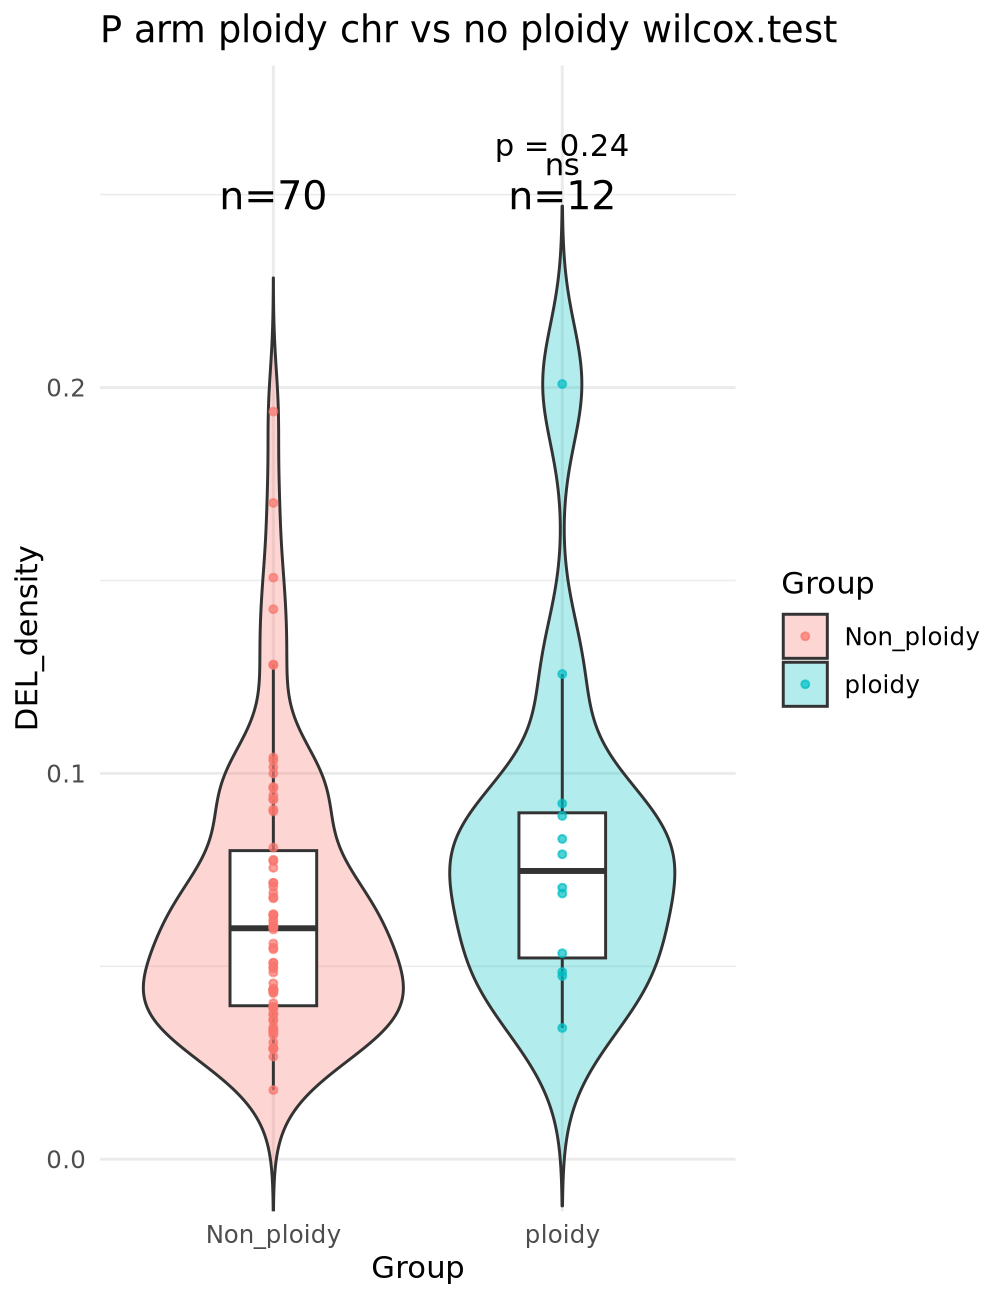

In [411]:
library(ggplot2)
library(ggpubr)

options(repr.plot.width = 5, repr.plot.height = 6.5, repr.plot.res = 200)

ggplot(final_df_transformed_p_arm, aes(x = Group, y = DEL_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.3, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "t.test", ref.group = "Non_ploidy", label = "p.signif", label.y = 0.255, label.size = 5) +  # Wilcoxon p-value (significance stars)
  stat_compare_means(method = "t.test", ref.group = "Non_ploidy", label = "p.format", label.y = 0.26, label.size = 5) +  # Wilcoxon p-value (exact value)
  stat_summary(fun.data = function(x) return(data.frame(y = 0.25, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "DEL_density", size = 12) +
  ggtitle("P arm ploidy chr vs no ploidy wilcox.test") +  # Axis labels
  theme_minimal() +
  coord_cartesian(ylim = c(0, 0.27))  # Adjust y-axis limits to ensure visibility



In [225]:
final_df_transformed_q_arm = final_df_transformed_q_arm %>% filter(DEL_density > 0 & DUP_density > 0)

Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”


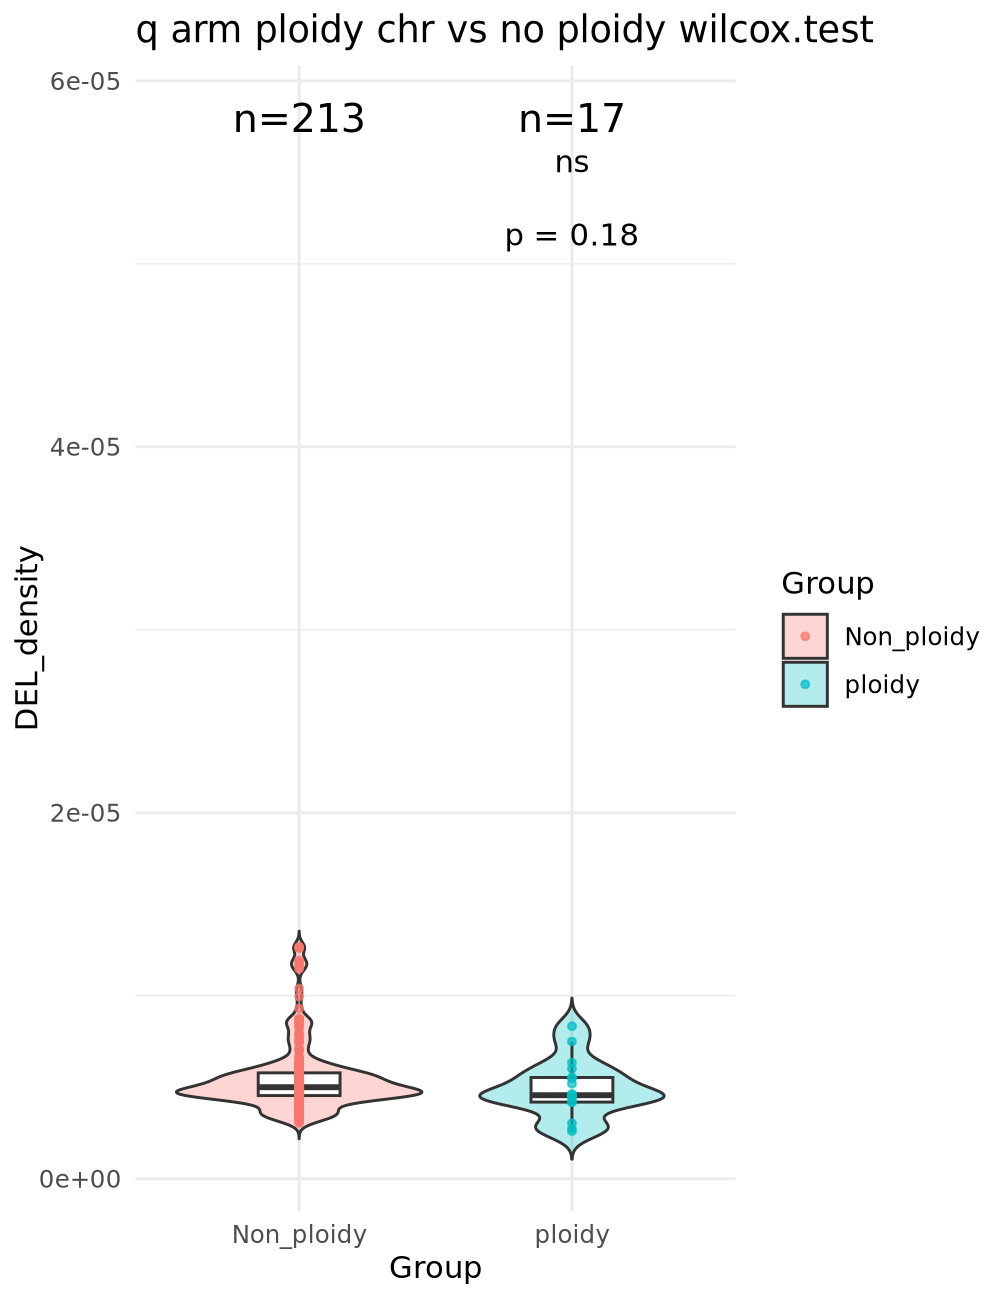

In [383]:


options(repr.plot.width = 5, repr.plot.height = 6.5, repr.plot.res = 200)

ggplot(final_df_transformed_q_arm, aes(x = Group, y = DEL_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.3, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.signif", label.y = 0.000055, label.size = 5) +  # Wilcoxon p-value (significance stars)
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.format", label.y = 0.000051, label.size = 5) +  # Wilcoxon p-value (exact value)
  stat_summary(fun.data = function(x) return(data.frame(y = 0.000058, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "DEL_density", size = 12) +
  ggtitle("q arm ploidy chr vs no ploidy wilcox.test") +  # Axis labels
  theme_minimal() #+
  #coord_cartesian(ylim = c(0, 0.3))  # Adjust y-axis limits to ensure visibility



Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”


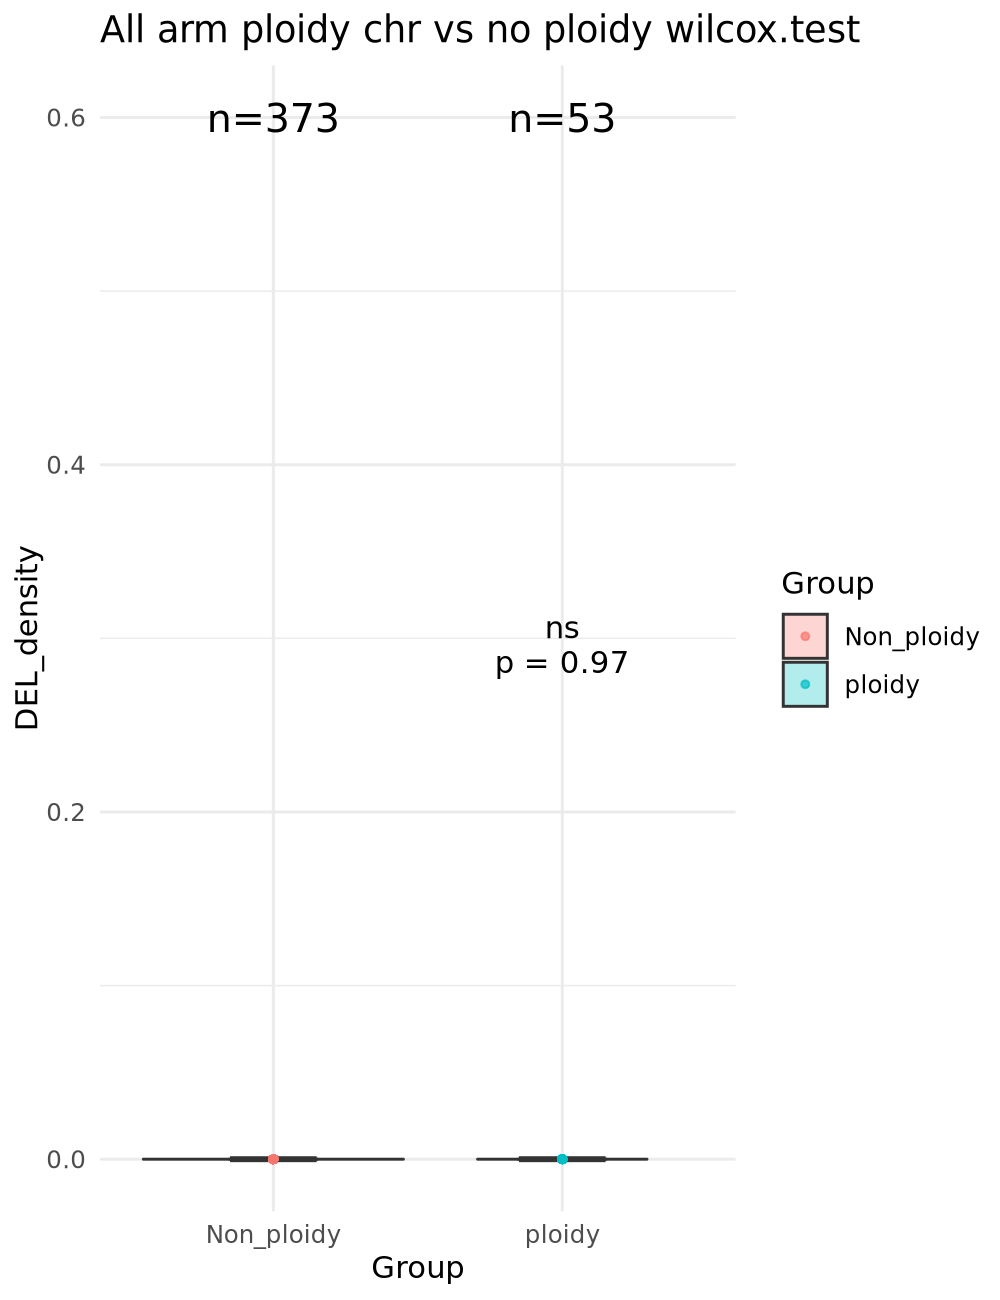

In [384]:
options(repr.plot.width = 5, repr.plot.height = 6.5, repr.plot.res = 200)

ggplot(final_df_transformed, aes(x = Group, y = DEL_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.3, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.signif", label.y = 0.30, label.size = 5) +  # Wilcoxon p-value (significance stars)
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.format", label.y = 0.28, label.size = 5) +  # Wilcoxon p-value (exact value)
  stat_summary(fun.data = function(x) return(data.frame(y = 0.6, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "DEL_density", size = 12) +
  ggtitle("All arm ploidy chr vs no ploidy wilcox.test") +  # Axis labels
  theme_minimal() +
  coord_cartesian(ylim = c(0, 0.6))  # Adjust y-axis limits to ensure visibility



In [385]:
head(final_df_transformed_p_arm)

,Group,SV_density,DEL_density,INV_density,DUP_density,BND_density,SampleID,chr,arm,arm_call,arm_cr_wmean,proportion_gain,proportion_loss
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,Non_ploidy,6.150184e-06,5.535166e-06,5.412162e-07,7.380221e-08,0,6269C,chr10,p,0,1.0198296,0.06896300,0.0000000
2,Non_ploidy,4.872656e-06,4.531380e-06,2.654365e-07,7.583900e-08,0,3188,chr11,p,0,1.0537342,0.02656887,0.0000000
3,ploidy,1.033306e-05,4.683058e-06,3.791950e-08,1.895975e-08,0,3988,chr11,p,-1,0.7432257,0.00000000,0.8995449
4,Non_ploidy,3.754030e-06,3.678191e-06,1.895975e-08,5.687925e-08,0,6265D,chr11,p,0,NA,0.00000000,0.1935732
5,ploidy,5.213931e-06,5.176012e-06,0.000000e+00,3.791950e-08,0,6439C,chr11,p,-1,0.6712259,0.00000000,0.8502031
6,ploidy,4.986414e-06,4.948495e-06,1.895975e-08,1.895975e-08,0,6478A,chr11,p,-1,0.6709894,0.00000000,0.9337048


Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”


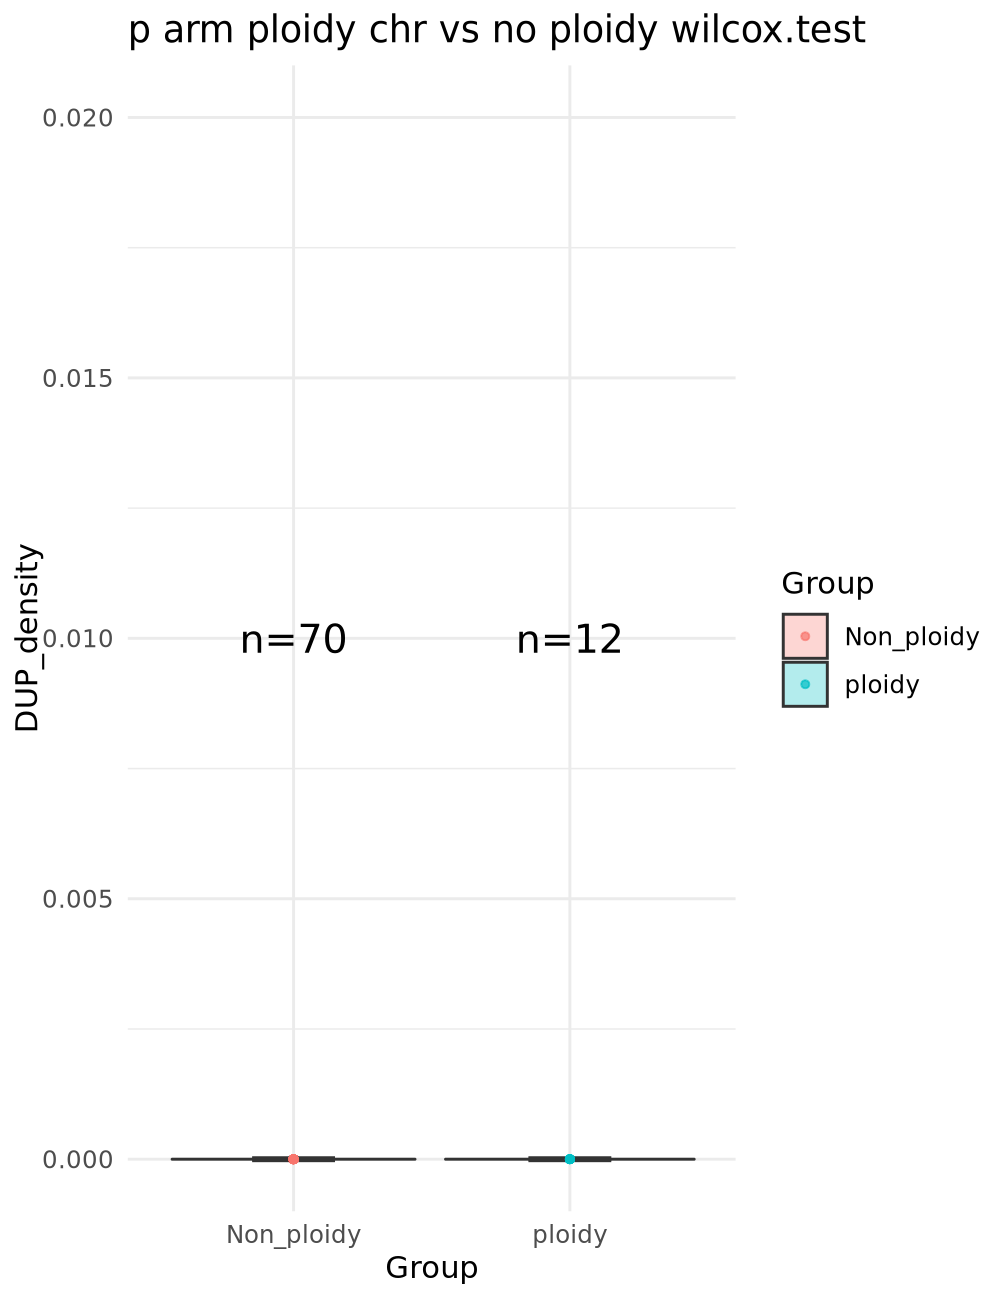

In [386]:
options(repr.plot.width = 5, repr.plot.height = 6.5, repr.plot.res = 200)

ggplot(final_df_transformed_p_arm, aes(x = Group, y = DUP_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.3, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.signif", label.y = 0.30, label.size = 5) +  # Wilcoxon p-value (significance stars)
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.format", label.y = 0.28, label.size = 5) +  # Wilcoxon p-value (exact value)
  stat_summary(fun.data = function(x) return(data.frame(y = max(x) + 0.01, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "DUP_density", size = 12) +
  ggtitle("p arm ploidy chr vs no ploidy wilcox.test") +  # Axis labels
  theme_minimal() +
  coord_cartesian(ylim = c(0, 0.02))  # Adjust y-axis limits to ensure visibility




Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”


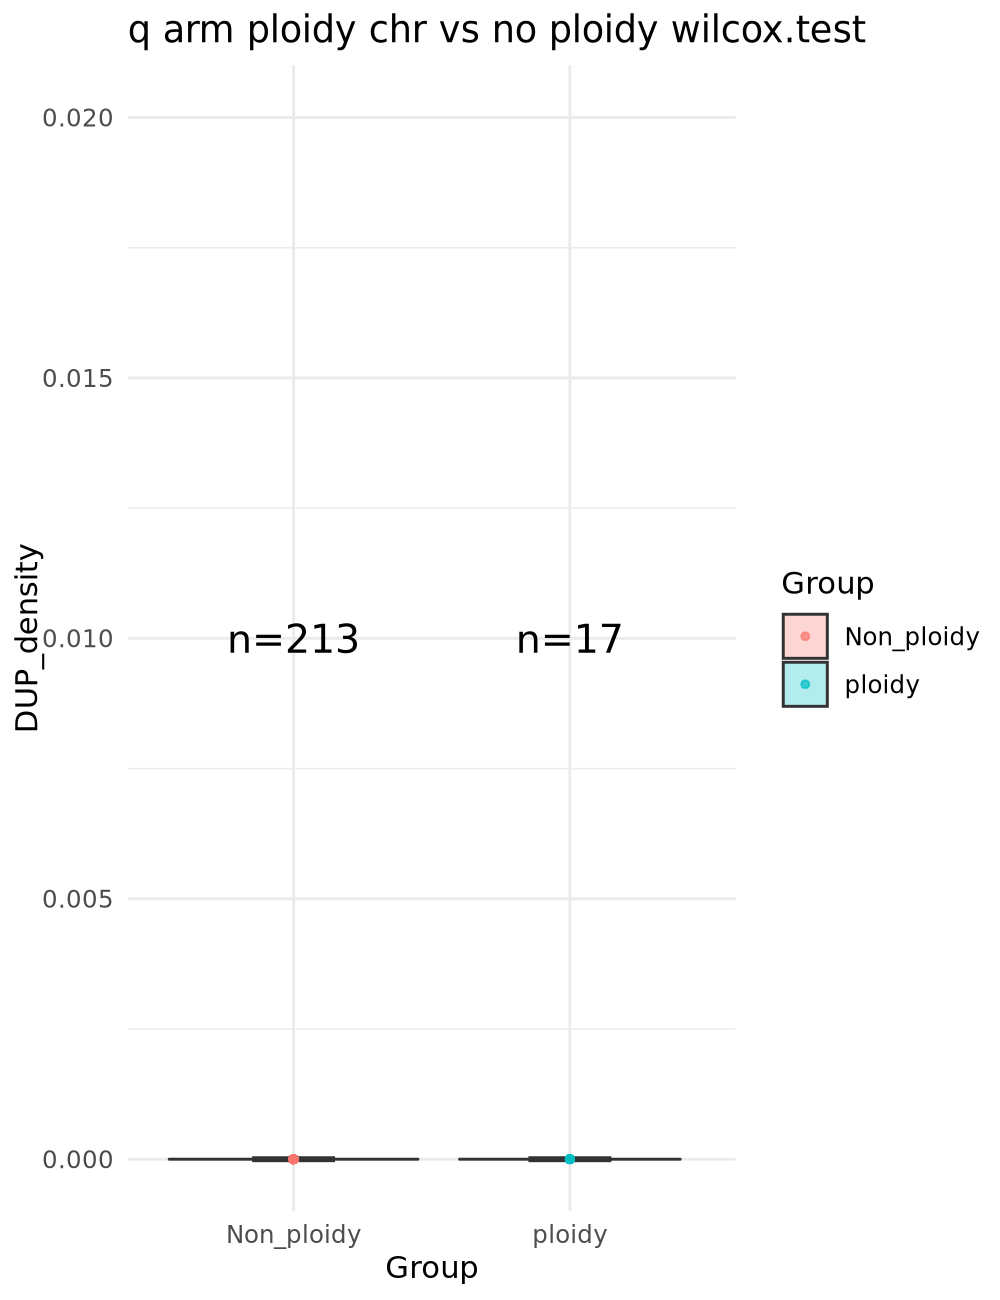

In [387]:
options(repr.plot.width = 5, repr.plot.height = 6.5, repr.plot.res = 200)

ggplot(final_df_transformed_q_arm, aes(x = Group, y = DUP_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.3, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.signif", label.y = 0.30, label.size = 5) +  # Wilcoxon p-value (significance stars)
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.format", label.y = 0.28, label.size = 5) +  # Wilcoxon p-value (exact value)
  stat_summary(fun.data = function(x) return(data.frame(y = max(x) + 0.01, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "DUP_density", size = 12) +
  ggtitle("q arm ploidy chr vs no ploidy wilcox.test") +  # Axis labels
  theme_minimal() +
  coord_cartesian(ylim = c(0, 0.02))  # Adjust y-axis limits to ensure visibility



Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”


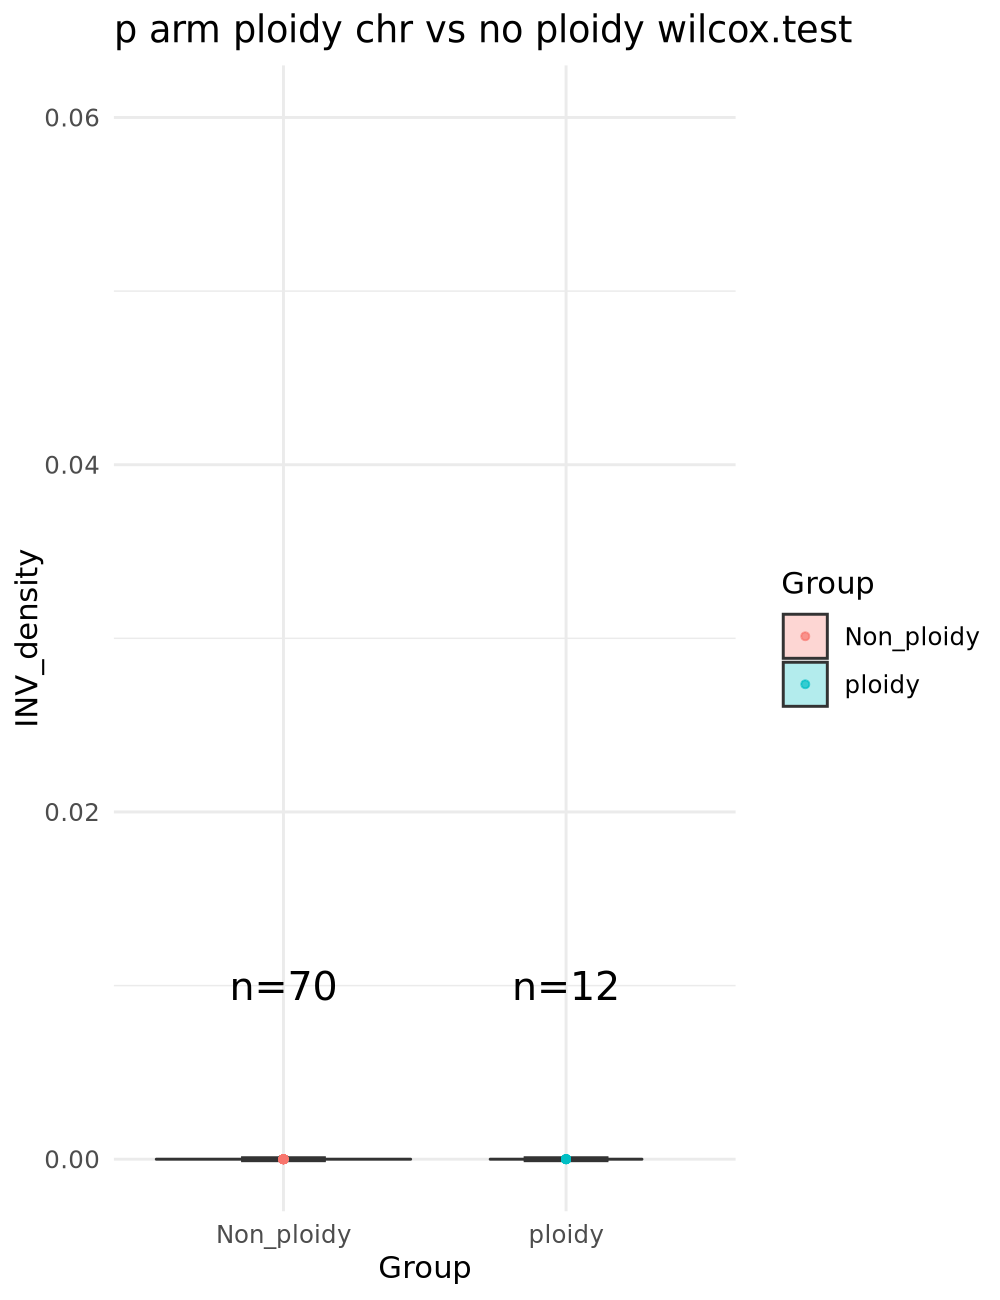

In [388]:
options(repr.plot.width = 5, repr.plot.height = 6.5, repr.plot.res = 200)

ggplot(final_df_transformed_p_arm, aes(x = Group, y = INV_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.3, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.signif", label.y = 0.30, label.size = 5) +  # Wilcoxon p-value (significance stars)
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.format", label.y = 0.28, label.size = 5) +  # Wilcoxon p-value (exact value)
  stat_summary(fun.data = function(x) return(data.frame(y = max(x) + 0.01, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "INV_density", size = 12) +
  ggtitle("p arm ploidy chr vs no ploidy wilcox.test") +  # Axis labels
  theme_minimal() +
  coord_cartesian(ylim = c(0, 0.06))  # Adjust y-axis limits to ensure visibility


Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”


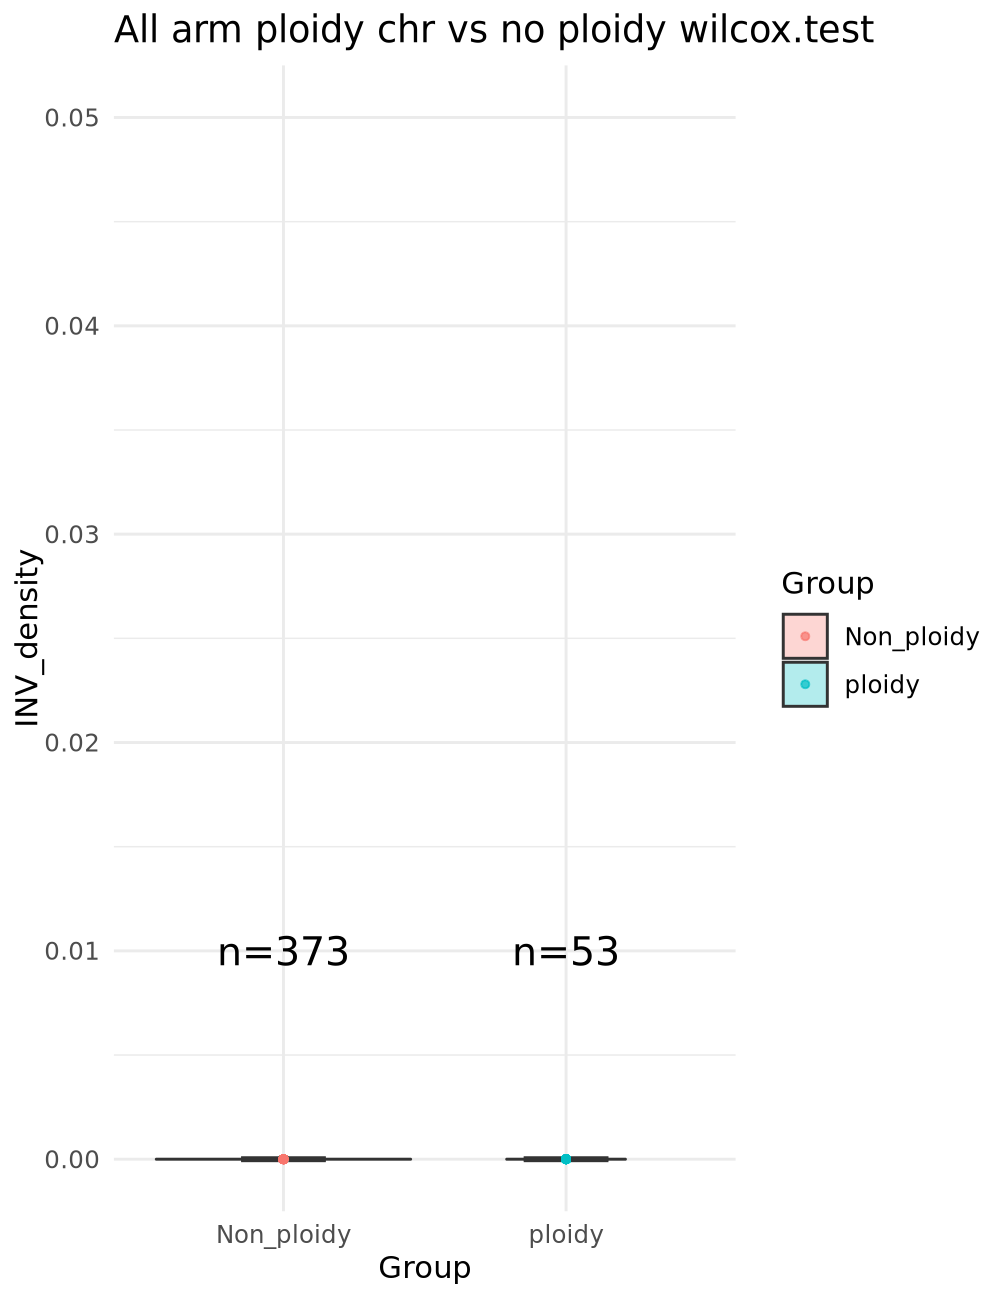

In [389]:
options(repr.plot.width = 5, repr.plot.height = 6.5, repr.plot.res = 200)

ggplot(final_df_transformed, aes(x = Group, y = INV_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.3, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.signif", label.y = 0.30, label.size = 5) +  # Wilcoxon p-value (significance stars)
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.format", label.y = 0.28, label.size = 5) +  # Wilcoxon p-value (exact value)
  stat_summary(fun.data = function(x) return(data.frame(y = max(x) + 0.01, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "INV_density", size = 12) +
  ggtitle("All arm ploidy chr vs no ploidy wilcox.test") +  # Axis labels
  theme_minimal() +
  coord_cartesian(ylim = c(0, 0.05))  # Adjust y-axis limits to ensure visibility



Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”


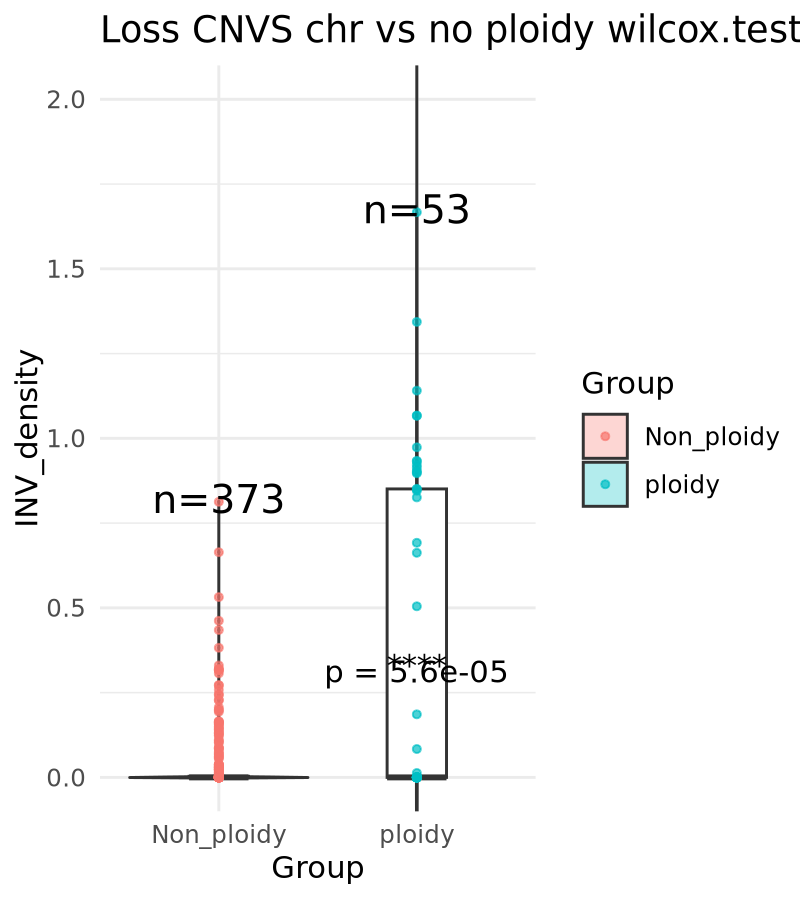

In [390]:
options(repr.plot.width = 4, repr.plot.height = 4.5, repr.plot.res = 200)

ggplot(final_df_transformed, aes(x = Group, y = proportion_loss, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.3, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.signif", label.y = 0.30, label.size = 5) +  # Wilcoxon p-value (significance stars)
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.format", label.y = 0.28, label.size = 5) +  # Wilcoxon p-value (exact value)
  stat_summary(fun.data = function(x) return(data.frame(y = max(x) + 0.01, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "INV_density", size = 12) +
  ggtitle("Loss CNVS chr vs no ploidy wilcox.test") +  # Axis labels
  theme_minimal() +
  coord_cartesian(ylim = c(0, 2))  # Adjust y-axis limits to ensure visibility
 

Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”


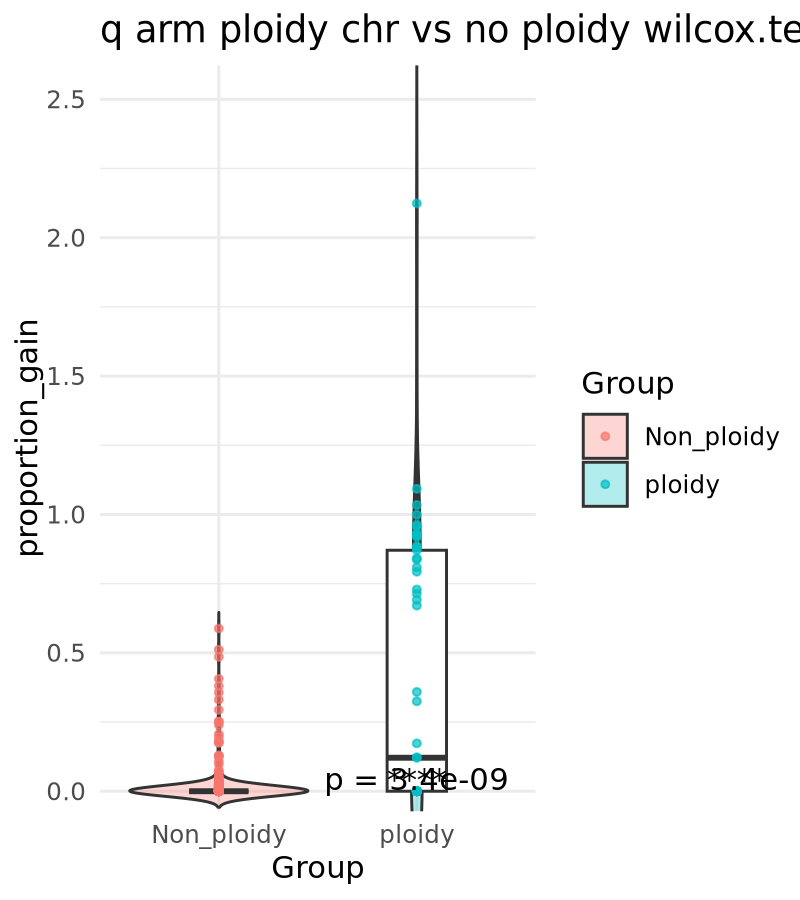

In [391]:
options(repr.plot.width = 4, repr.plot.height = 4.5, repr.plot.res = 200)

ggplot(final_df_transformed, aes(x = Group, y = proportion_gain, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +                                   # Draw the violin plot
  geom_boxplot(width = 0.3, fill = "white", outlier.shape = NA) +            # Add boxplot inside violin
  geom_point(aes(color = Group), size = 1, alpha = 0.7) +                     # Color dots by Group with alpha
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.signif", label.y = 0.0049, label.size = 12) +  # Adjust text size and position for p-value
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.format", label.y = 0.0045, label.size = 12) +  # Add p-value
  labs(x = "Group", y = "proportion_gain", size = 12) +
  ggtitle("q arm ploidy chr vs no ploidy wilcox.test") +                                    # Axis labels
  theme_minimal() +
  coord_cartesian(ylim = c(0.05, 2.5))

Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", :
“Ignoring unknown parameters: `label.size`”


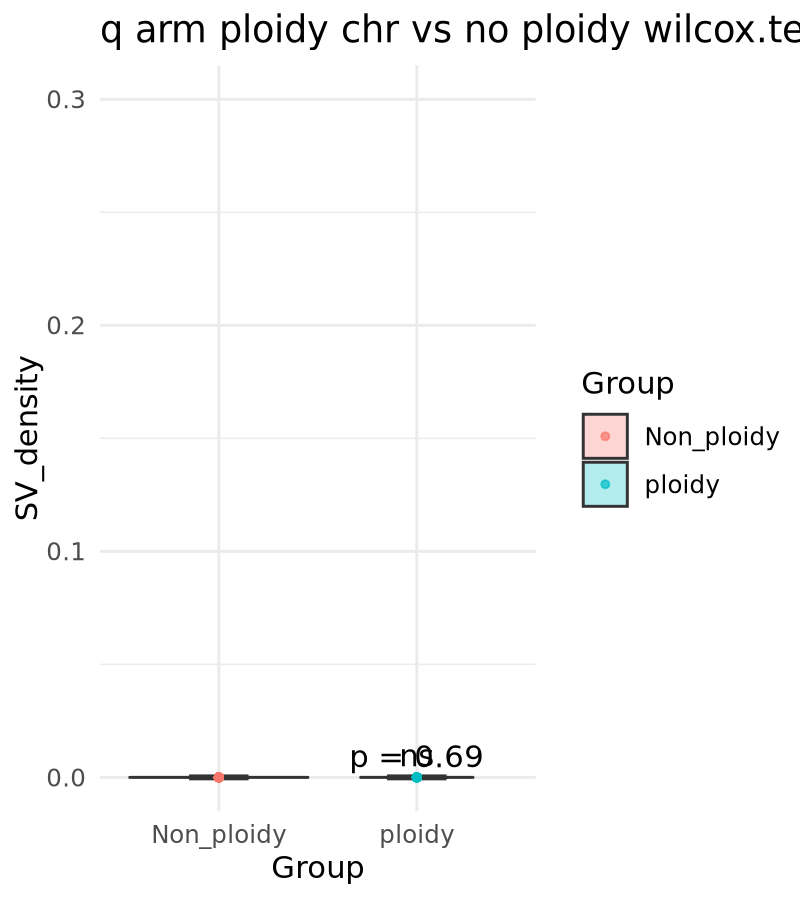

In [392]:
ggplot(final_df_transformed, aes(x = Group, y = SV_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +
  geom_boxplot(width = 0.3, fill = "white", outlier.shape = NA) +
  geom_point(aes(color = Group), size = 1, alpha = 0.7) +
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.signif", label.y = 0.0049, label.size = 12) +
  stat_compare_means(method = "wilcox.test", ref.group = "Non_ploidy", label = "p.format", label.y = 0.0045, label.size = 12) +
  labs(x = "Group", y = "SV_density", size = 12) +
  ggtitle("q arm ploidy chr vs no ploidy wilcox.test") +
  theme_minimal() +
  coord_cartesian(ylim = c(0, 0.3))  # Replace min_value and max_value with your desired limits


In [393]:
library(ggplot2)
library(ggsignif)

# Define comparisons
comparisons <- list(c("Non_ploidy", "ploidy"))

options(repr.plot.width = 4, repr.plot.height = 5, repr.plot.res = 200)

# Create the plot
ggplot(final_df_transformed_p, aes(x = Group, y = proportion_loss, fill = Group)) +
#geom_jitter(size = 2) +
  stat_summary(fun = mean, geom = "bar", alpha = 0.6, width = 0.6, color = "black") + # Bar plot of mean values
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.2) + # Error bars for standard error
  geom_signif(comparisons = comparisons,
              map_signif_level = TRUE,
              textsize = 5,
              y_position = max(final_df_transformed$proportion_loss, na.rm = TRUE) * 0.25) + # Significance bars
  labs(x = "Group", y = "Proportion Loss") +
  ggtitle("CNVs proportion vs ploidy and no ploidy") +
  theme_minimal()


ERROR: Error: object 'final_df_transformed_p' not found


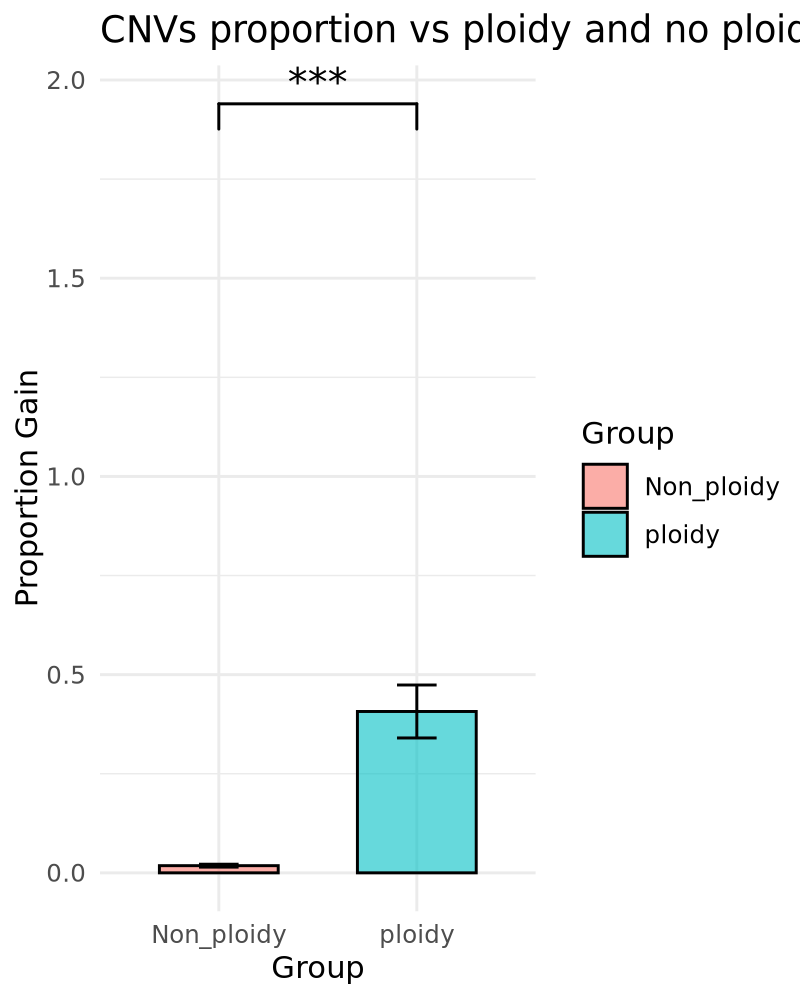

In [394]:
library(ggplot2)
library(ggsignif)

# Define comparisons
comparisons <- list(c("Non_ploidy", "ploidy"))

# Create the plot
ggplot(final_df_transformed, aes(x = Group, y = proportion_gain, fill = Group)) +
  stat_summary(fun = mean, geom = "bar", alpha = 0.6, width = 0.6, color = "black") + # Bar plot of mean values
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.2) + # Error bars for standard error
  geom_signif(comparisons = comparisons,
              map_signif_level = TRUE,
              textsize = 5,
              y_position = max(final_df_transformed$proportion_loss, na.rm = TRUE) * 1.1) + # Significance bars
  labs(x = "Group", y = "Proportion Gain") +
  ggtitle("CNVs proportion vs ploidy and no ploidy") +
  theme_minimal()
